In [21]:
import pandas as pd
import re
import csv
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
def limpar_texto(text):
    if not isinstance(text, str):
        return ""
    # Remover tags HTML que aparecem muito em phishings
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remover URLs explícitas para o modelo focar na linguagem do texto
    text = re.sub(r'http\s+|www\.\S+', ' [url] ', text)
    # Remover quebras de linha, tabulações e múltiplos espaços
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

# ==========================================
# 1. CARREGAR E PADRONIZAR NAZARIO
# ==========================================
print("Carregando Nazario...")
try:
    df_naz = pd.read_csv("Nazario_5.csv", engine='python', on_bad_lines='skip')

    # Identificar coluna de texto do Nazario dinamicamente
    col_texto_naz = None
    for col in df_naz.columns:
        if col.lower() in ['body', 'text', 'message', 'email', 'email text']:
            col_texto_naz = col
            break
    if not col_texto_naz:
        col_texto_naz = df_naz.select_dtypes(include=['object']).columns[0]

    df_naz_clean = pd.DataFrame({
        'text': df_naz[col_texto_naz].apply(limpar_texto),
        'label': 1  # Nazario é majoritariamente/totalmente phishing
    })
    print(f"Nazario carregado com sucesso! Formato: {df_naz_clean.shape}")
except Exception as e:
    print(f"Erro ao carregar Nazario: {e}")

# ==========================================
# 2. CARREGAR E PADRONIZAR ENRON (SOLUÇÃO ROBUSTA)
# ==========================================
print("\nCarregando Enron...")
try:
    # Usando o motor em Python e pulando linhas malformadas que causavam o EOF error
    df_enron = pd.read_csv("enron_fraud.csv", engine='python', on_bad_lines='skip')
    print("Enron lido pelo interpretador Python.")
except Exception as e:
    print(f"Aviso no motor Python: {e}. Tentando fallback com codificação alternativa...")
    df_enron = pd.read_csv("enron_fraud.csv", encoding='utf-8', encoding_errors='replace', on_bad_lines='skip')

# Identificação dinâmica das colunas do Enron para evitar KeyError
col_texto_enron = None
for col in df_enron.columns:
    if col.lower() in ['body', 'text', 'message', 'email', 'content']:
        col_texto_enron = col
        break
if not col_texto_enron:
    col_texto_enron = df_enron.select_dtypes(include=['object']).columns[0]

col_label_enron = None
for col in df_enron.columns:
    if col.lower() in ['target', 'label', 'fraud', 'class']:
        col_label_enron = col
        break
if not col_label_enron:
    col_label_enron = df_enron.select_dtypes(include=['number']).columns[0]

print(f"Colunas identificadas no Enron -> Texto: '{col_texto_enron}' | Label: '{col_label_enron}'")

df_enron_clean = pd.DataFrame({
    'text': df_enron[col_texto_enron].apply(limpar_texto),
    'label': df_enron[col_label_enron].astype(int)
})
print(f"Enron processado com sucesso! Formato: {df_enron_clean.shape}")

# ==========================================
# 3. FUSÃO E TRATAMENTO DE DESBALANCEAMENTO
# ==========================================
print("\nUnificando os conjuntos de dados...")
df_completo = pd.concat([df_naz_clean, df_enron_clean], ignore_index=True)

# Remover linhas vazias ou nulas geradas pós-limpeza
df_completo.dropna(subset=['text'], inplace=True)
df_completo = df_completo[df_completo['text'] != ""]

print(f"Distribuição total das classes combinadas:\n{df_completo['label'].value_counts()}")

# Amostragem equilibrada (Undersampling da classe majoritária)
min_samples = df_completo['label'].value_counts().min()
df_balanced = df_completo.groupby('label').sample(n=min_samples, random_state=42).reset_index(drop=True)

print(f"\nDistribuição final após o balanceamento:\n{df_balanced['label'].value_counts()}")

Carregando Nazario...
Nazario carregado com sucesso! Formato: (3063, 2)

Carregando Enron...
Enron lido pelo interpretador Python.
Colunas identificadas no Enron -> Texto: 'Body' | Label: 'Label'
Enron processado com sucesso! Formato: (447274, 2)

Unificando os conjuntos de dados...
Distribuição total das classes combinadas:
0    443574
1      5388
Name: label, dtype: int64

Distribuição final após o balanceamento:
0    5388
1    5388
Name: label, dtype: int64


In [23]:
# Mostra a lista exata com o nome de todas as colunas presentes
print("Colunas presentes no dataset unificado:")
print(df_completo.columns.tolist())

# Mostra o formato do dataset (Número de linhas, Número de colunas)
print(f"\nFormato do dataset unificado: {df_completo.shape}")

Colunas presentes no dataset unificado:
['text', 'label']

Formato do dataset unificado: (448962, 2)


In [24]:
X = df_balanced["text"]
y = df_balanced["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Treino:", len(X_train))
print("Teste :", len(X_test))

Treino: 8620
Teste : 2156


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

modelo_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2)
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

modelo_tfidf.fit(X_train, y_train)

pred = modelo_tfidf.predict(X_test)

print("\nTF-IDF + Logistic Regression")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1       :", f1_score(y_test, pred))


TF-IDF + Logistic Regression
Accuracy : 0.9359925788497218
Precision: 0.9359925788497218
Recall   : 0.9359925788497218
F1       : 0.9359925788497218


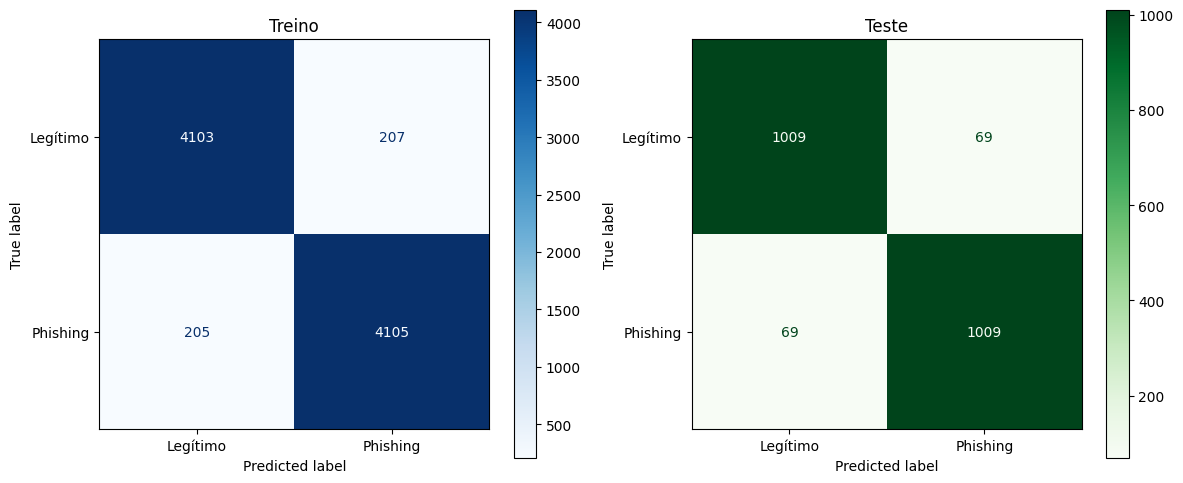

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# previsões
y_pred_train = modelo_tfidf.predict(X_train)
y_pred_test = modelo_tfidf.predict(X_test)

# matriz treino
cm_train = confusion_matrix(y_train, y_pred_train)

# matriz teste
cm_test = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=["Legítimo", "Phishing"]).plot(
    cmap="Blues",
    values_format="d",
    ax=ax[0]
)
ax[0].set_title("Treino")

ConfusionMatrixDisplay(cm_test, display_labels=["Legítimo", "Phishing"]).plot(
    cmap="Greens",
    values_format="d",
    ax=ax[1]
)
ax[1].set_title("Teste")

plt.tight_layout()
plt.show()

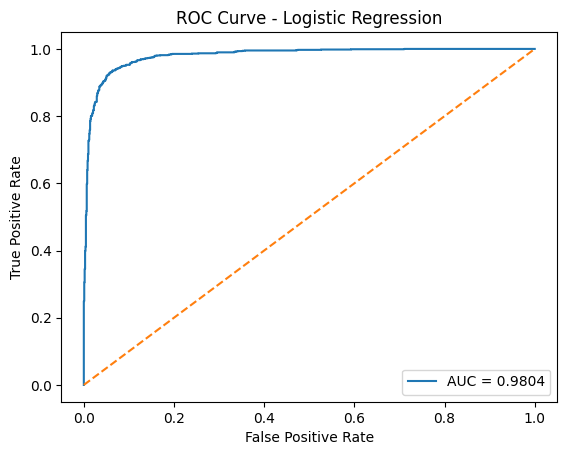

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probabilidades da classe positiva (phishing)
y_proba = modelo_tfidf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [16]:
!ollama pull llama3.2:3b


]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling dde5aa3fc5ff:   0% ▕                  ▏ 3.6 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff:   0% ▕                  ▏ 5.6 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff:   0% ▕                  ▏ 6.6 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff:   0% ▕                  ▏ 8.8 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff:   1% ▕                  ▏  10 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff:   1% ▕                  ▏  12 MB/2.0 GB                  pulling man

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import ollama

def classificar_email(modelo, texto):

    prompt = f"""
Você é um especialista em segurança de e-mails.

Sua tarefa é identificar se um email é PHISHING ou LEGÍTIMO.

Critérios de phishing:
- solicitações urgentes
- links suspeitos
- pedidos de senha ou login
- ameaças ou pressão psicológica
- domínios estranhos

Responda APENAS com:
0 = legítimo
1 = phishing

EMAIL:
{texto}
"""

    resposta = ollama.chat(
        model=modelo,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    saida = resposta["message"]["content"].strip()

    if "1" in saida:
        return 1

    return 0

def avaliar_llm(model_name):

    X_eval = X_test.sample(200, random_state=42)
    y_eval = y_test.loc[X_eval.index]

    preds = []

    for texto in X_eval:

        pred = classificar_email(
            model_name,
            texto[:500]   # mais leve
        )

        preds.append(pred)

    print(f"\nModelo: {model_name}")

    print("Accuracy :", accuracy_score(y_eval, preds))
    print("Precision:", precision_score(y_eval, preds))
    print("Recall   :", recall_score(y_eval, preds))
    print("F1       :", f1_score(y_eval, preds))


Modelo: qwen2.5:1.5b
Accuracy : 0.545
Precision: 0.5489130434782609
Recall   : 0.926605504587156
F1       : 0.689419795221843
Tempo total: 1089.318259716034


In [29]:
import time

start = time.time()

avaliar_llm("gemma2:2b")

print("Tempo total:", time.time() - start)


Modelo: gemma2:2b
Accuracy : 0.69
Precision: 0.7526881720430108
Recall   : 0.6422018348623854
F1       : 0.6930693069306931
Tempo total: 1462.0333003997803


In [30]:
import time

start = time.time()

avaliar_llm("llama3.2:3b")

print("Tempo total:", time.time() - start)


Modelo: llama3.2:3b
Accuracy : 0.61
Precision: 0.6396396396396397
Recall   : 0.6513761467889908
F1       : 0.6454545454545454
Tempo total: 2139.7933571338654
